# Task 2 — Time Series Forecasting

This notebook runs three forecasting experiments: Delhi weather, Lorenz system, and synthetic tumour-growth data. Plots are displayed inside the notebook.

# Declaration of AI Usage

This research notebook was developed with the assistance of generative artificial intelligence (AI) tools as a supplementary aid. AI was used for the following purposes:

* Studying and understanding the concepts, algorithms, and models relevant to this research.
* Assisting with code development, debugging, and improving the overall implementation.
* Enhancing the presentation of the notebook, including improving figures, visualizations, and refining the wording of comments and markdown sections to make them clearer and more suitable for a research notebook.

All AI-generated suggestions were carefully reviewed, verified, and modified where necessary before being incorporated into the final notebook. The authors take full responsibility for the methodology, implementation, results, analysis, and conclusions presented in this work.


## 1. Imports and settings

Load libraries, set random seeds, and define a small RMSE helper.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))


## 2. Helper functions

These functions create sliding windows, build the neural network, and roll forecasts forward recursively.

In [5]:
def make_windows(series, L):
    X, Y = [], []
    for t in range(L, len(series)):
        X.append(series[t-L:t])
        Y.append(series[t])
    return np.array(X), np.array(Y)


def build_forecaster(L, d, hidden=(64, 32), lr=1e-3, l2=1e-3, act="relu"):
    model = keras.Sequential([layers.Input(shape=(L, d)), layers.Flatten()])
    for h in hidden:
        model.add(
            layers.Dense(
                h, activation=act,
                kernel_regularizer=regularizers.l2(l2)
            )
        )
    model.add(layers.Dense(d))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model


def rollout(model, seed_window, steps):
    win = seed_window.copy()
    out = []
    for _ in range(steps):
        y_pred = model.predict(win[None, ...], verbose=0)[0]
        out.append(y_pred)
        win = np.vstack([win[1:], y_pred])
    return np.array(out)

# Part A — Delhi Weather

Use past weather values to forecast the next days of temperature.

## 3. Load and clean weather data

Read the train/test CSV files and fix unrealistic pressure values by interpolation.

In [6]:
TRAIN_WEATHER = Path("/content/sample_data/DailyDelhiClimateTrain.csv")
TEST_WEATHER = Path("/content/sample_data/DailyDelhiClimateTest.csv")

cols = ["meantemp", "humidity", "wind_speed", "meanpressure"]
weather_train_df = pd.read_csv(TRAIN_WEATHER)
weather_test_df = pd.read_csv(TEST_WEATHER)

for data in (weather_train_df, weather_test_df):
    data.loc[~data["meanpressure"].between(950, 1050), "meanpressure"] = np.nan
    data["meanpressure"] = data["meanpressure"].interpolate().bfill().ffill()

train_raw = weather_train_df[cols].values.astype(float)
test_raw = weather_test_df[cols].values.astype(float)

weather_train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


## 4. Prepare weather windows

Standardise the variables and create 30-day windows for next-step prediction.

In [7]:
L_weather = 30
sc_weather = StandardScaler().fit(train_raw)
train_s = sc_weather.transform(train_raw)
test_s = sc_weather.transform(test_raw)

X_weather, Y_weather = make_windows(train_s, L_weather)
print("Window input shape:", X_weather.shape)
print("Target shape:", Y_weather.shape)


Window input shape: (1432, 30, 4)
Target shape: (1432, 4)


## 5. Train the weather model

Train a feed-forward model that predicts the next weather vector from the previous 30 days.

In [8]:
weather_model = build_forecaster(L_weather, len(cols), hidden=(64, 32))
weather_history = weather_model.fit(
    X_weather, Y_weather,
    validation_split=0.15,
    epochs=200,
    batch_size=64,
    verbose=0,
    callbacks=[keras.callbacks.EarlyStopping("val_loss", patience=20, restore_best_weights=True)]
)

print("Best validation MSE:", round(min(weather_history.history["val_loss"]), 4))


Best validation MSE: 0.402


## 6. Evaluate weather forecasts

Roll the model forward for 10 days and show the temperature error by horizon.

In [9]:
full_weather = np.vstack([train_s, test_s])
offset = len(train_s)
K_weather = 10

squared_errors = np.zeros(K_weather)
n = 0
one_step_pairs = []

for i in range(offset, len(full_weather) - K_weather):
    pred_scaled = rollout(weather_model, full_weather[i-L_weather:i], K_weather)
    pred_temp = sc_weather.inverse_transform(pred_scaled)[:, 0]
    true_temp = sc_weather.inverse_transform(full_weather[i:i+K_weather])[:, 0]
    squared_errors += (pred_temp - true_temp) ** 2
    n += 1
    one_step_pairs.append((pred_temp[0], true_temp[0]))

k_rmse = np.sqrt(squared_errors / n)
one_step_pairs = np.array(one_step_pairs)

print("Temperature RMSE by horizon:", np.round(k_rmse, 2))
display(pd.DataFrame({"horizon_day": np.arange(1, K_weather + 1), "temp_RMSE_C": k_rmse}).round(2))


Temperature RMSE by horizon: [2.91 3.47 3.85 4.1  4.21 4.31 4.42 4.5  4.6  4.58]


,horizon_day,temp_RMSE_C
0,1,2.91
1,2,3.47
2,3,3.85
3,4,4.10
4,5,4.21
5,6,4.31
6,7,4.42
7,8,4.50
8,9,4.60
9,10,4.58


## 7. Plot weather results

Show the raw temperature series, one-step forecast, and k-step error.

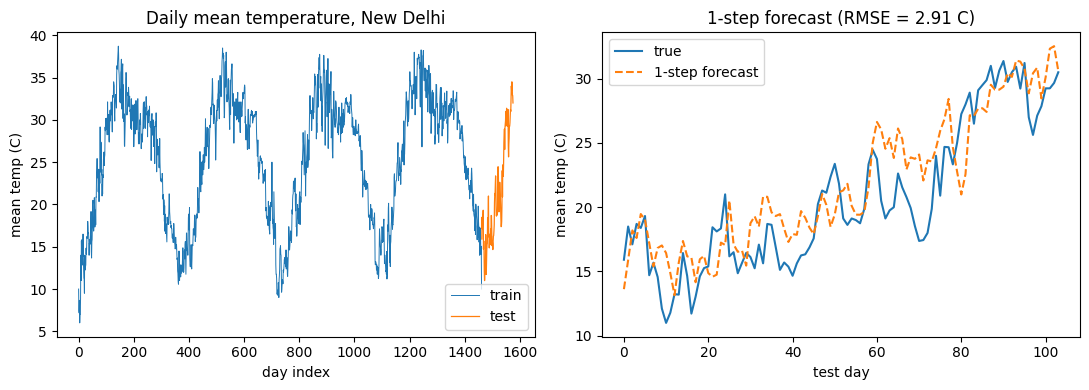

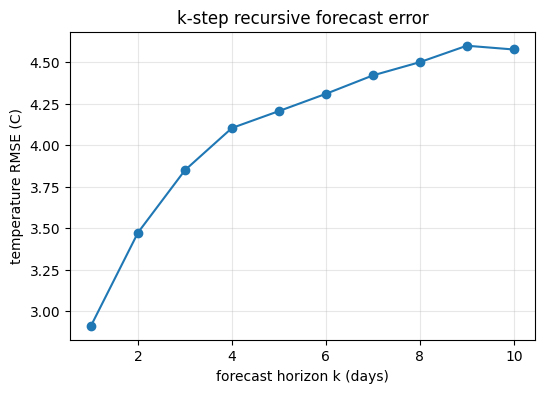

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(train_raw[:, 0], linewidth=0.7, label="train")
ax[0].plot(range(len(train_raw), len(train_raw) + len(test_raw)), test_raw[:, 0], linewidth=0.9, label="test")
ax[0].set_title("Daily mean temperature, New Delhi")
ax[0].set_xlabel("day index")
ax[0].set_ylabel("mean temp (C)")
ax[0].legend()

ax[1].plot(one_step_pairs[:, 1], label="true")
ax[1].plot(one_step_pairs[:, 0], "--", label="1-step forecast")
ax[1].set_title(f"1-step forecast (RMSE = {k_rmse[0]:.2f} C)")
ax[1].set_xlabel("test day")
ax[1].set_ylabel("mean temp (C)")
ax[1].legend()
plt.tight_layout()
plt.savefig("figures/fig_weather_overview.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(6, 4))
plt.plot(range(1, K_weather + 1), k_rmse, "o-")
plt.xlabel("forecast horizon k (days)")
plt.ylabel("temperature RMSE (C)")
plt.title("k-step recursive forecast error")
plt.grid(alpha=0.3)
plt.savefig("figures/fig_weather_kstep.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()

# Part B — Lorenz System

## 8. Simulate Lorenz data

Generate the Lorenz trajectory by solving the differential equations.

In [11]:
sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0
dt = 0.01

def lorenz_rhs(t, u):
    x, y, z = u
    return [
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ]

solution = solve_ivp(
    lorenz_rhs, [0, 60], [1, 1, 1],
    t_eval=np.arange(0, 60, dt),
    rtol=1e-9, atol=1e-9
)

lorenz_traj = solution.y.T[1000:]
print("Lorenz trajectory shape:", lorenz_traj.shape)


Lorenz trajectory shape: (5000, 3)


## 9. Train the Lorenz forecaster

Use a 20-step window and train on the first 70% of the simulated trajectory.

In [12]:
L_lorenz = 20
split = int(0.7 * len(lorenz_traj))

sc_lorenz = StandardScaler().fit(lorenz_traj[:split])
lorenz_scaled = sc_lorenz.transform(lorenz_traj)

X_lorenz, Y_lorenz = make_windows(lorenz_scaled[:split], L_lorenz)

lorenz_model = build_forecaster(L_lorenz, 3, hidden=(64, 64), l2=1e-5, act="tanh")
lorenz_model.fit(X_lorenz, Y_lorenz, epochs=300, batch_size=128, verbose=0)

## 10. Roll out the Lorenz forecast

Predict 400 future steps and calculate the Euclidean prediction error.

In [13]:
K_lorenz = 400
lorenz_pred = sc_lorenz.inverse_transform(rollout(lorenz_model, lorenz_scaled[split:split+L_lorenz], K_lorenz))
lorenz_true = sc_lorenz.inverse_transform(lorenz_scaled[split+L_lorenz:split+L_lorenz+K_lorenz])
lorenz_error = np.linalg.norm(lorenz_pred - lorenz_true, axis=1)
lorenz_time = np.arange(K_lorenz) * dt

print(f"Error at k=10: {lorenz_error[9]:.2f}")
print(f"Error at k=100: {lorenz_error[99]:.2f}")


Error at k=10: 0.10
Error at k=100: 9.57


## 11. Plot Lorenz results

Show the attractor, the x-coordinate rollout, and the exponential error growth.

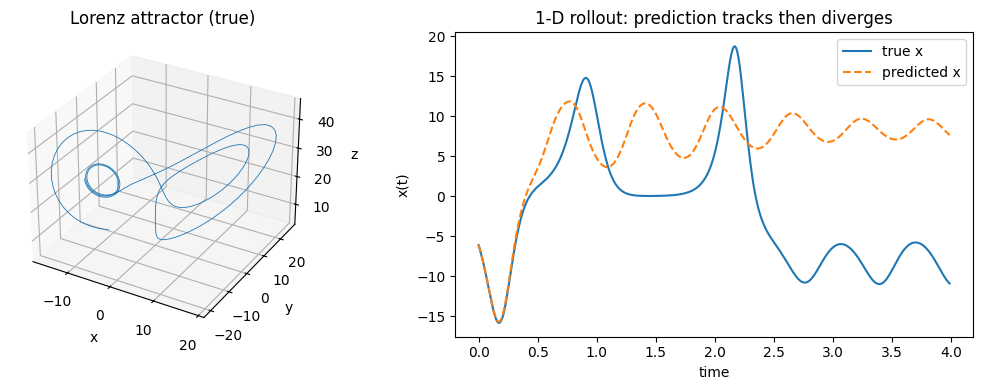

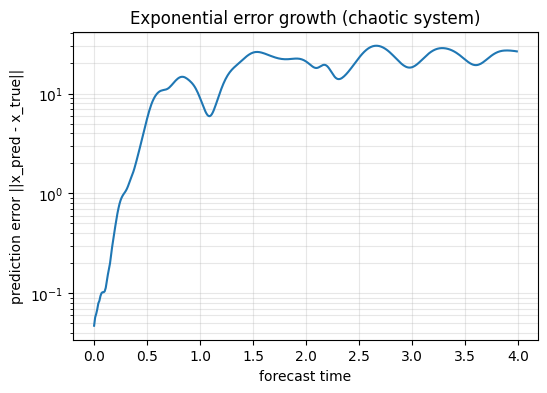

In [14]:
fig = plt.figure(figsize=(11, 4))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax0.plot(lorenz_true[:, 0], lorenz_true[:, 1], lorenz_true[:, 2], linewidth=0.6)
ax0.set_title("Lorenz attractor (true)")
ax0.set_xlabel("x")
ax0.set_ylabel("y")
ax0.set_zlabel("z")

ax1 = fig.add_subplot(1, 2, 2)
ax1.plot(lorenz_time, lorenz_true[:, 0], label="true x")
ax1.plot(lorenz_time, lorenz_pred[:, 0], "--", label="predicted x")
ax1.set_title("1-D rollout: prediction tracks then diverges")
ax1.set_xlabel("time")
ax1.set_ylabel("x(t)")
ax1.legend()
plt.tight_layout()
plt.savefig("figures/fig_lorenz_traj.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(6, 4))
plt.semilogy(lorenz_time, lorenz_error + 1e-6)
plt.xlabel("forecast time")
plt.ylabel("prediction error ||x_pred - x_true||")
plt.title("Exponential error growth (chaotic system)")
plt.grid(alpha=0.3, which="both")
plt.savefig("figures/fig_lorenz_error.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()


# Part C — Synthetic Tumour Growth

Generate virtual tumour-volume trajectories and predict the 12-month outcome from early measurements.

## 12. Define the tumour simulator

Simulate proliferating and doomed tumour-cell compartments over 12 months.

In [15]:
def simulate_patient(params):
    steps_per_month = 30
    n_days = 12 * steps_per_month
    dt_month = 1.0 / steps_per_month
    P = params["V0"]
    D = 0.0
    volumes = []

    radiation_days = {int(round(day)) for day in np.arange(2, 44, 7)}
    chemo_days = {int(round(month * steps_per_month)) for month in range(4)}

    for day in range(n_days):
        if day in radiation_days:
            SF = np.exp(-params["alpha"] * params["dose"] - params["beta"] * params["dose"] ** 2)
            killed = (1 - SF) * P
            P -= killed
            D += killed

        if day in chemo_days:
            killed = params["kappa"] * P
            P -= killed
            D += killed

        P += params["lam"] * P * dt_month
        D -= params["mu"] * D * dt_month
        volumes.append(P + D)

    return np.array(volumes)


def sample_patient_params():
    return {
        "V0": np.random.uniform(20, 120),
        "lam": np.random.uniform(0.02, 0.08),
        "mu": np.random.uniform(0.05, 0.15),
        "alpha": np.random.uniform(0.2, 0.4),
        "beta": np.random.uniform(0.02, 0.06),
        "dose": np.random.uniform(1.8, 2.5),
        "kappa": np.random.uniform(0.1, 0.35),
    }

print("Tumour simulator ready")


Tumour simulator ready


## 13. Generate tumour data

Create 400 virtual patients, use early weekly measurements as input, and monthly volumes as targets.

In [16]:
N_patients = 400
series = np.array([
    simulate_patient(sample_patient_params()) * (1 + np.random.normal(0, 0.05, 360))
    for _ in range(N_patients)
])

weekly_input = series[:, ::7][:, :8]
monthly_target = series[:, ::30][:, :12]

input_scaler = StandardScaler().fit(weekly_input[:300])
output_scaler = StandardScaler().fit(monthly_target[:300])

X_tumour_train = input_scaler.transform(weekly_input[:300])
Y_tumour_train = output_scaler.transform(monthly_target[:300])
X_tumour_test = input_scaler.transform(weekly_input[300:])
Y_tumour_test = output_scaler.transform(monthly_target[300:])

print("Input shape:", X_tumour_train.shape)
print("Target shape:", Y_tumour_train.shape)


Input shape: (300, 8)
Target shape: (300, 12)


## 14. Train the tumour model

Train a direct multi-horizon model that outputs all 12 monthly volumes at once.

In [17]:
tumour_model = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-3)),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-3)),
    layers.Dense(12),
])

tumour_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
tumour_history = tumour_model.fit(
    X_tumour_train, Y_tumour_train,
    validation_split=0.15,
    epochs=500,
    batch_size=32,
    verbose=0,
    callbacks=[keras.callbacks.EarlyStopping("val_loss", patience=40, restore_best_weights=True)]
)

print("Best validation MSE:", round(min(tumour_history.history["val_loss"]), 4))


Best validation MSE: 0.1003


## 15. Evaluate and plot tumour predictions

Print RMSE/MAE and show true versus predicted trajectories for five patients.

Tumour RMSE: 5.31
Tumour MAE: 3.86


,month,mean_relative_error_percent
0,1,2.67
1,2,4.62
2,3,5.44
3,4,6.06
4,5,8.56
5,6,10.09
6,7,11.82
7,8,13.45
8,9,16.08
9,10,18.32


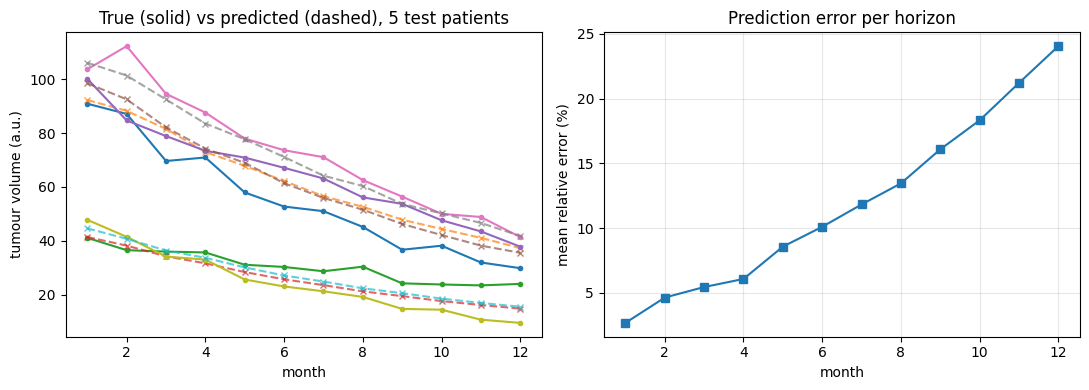

In [18]:
tumour_pred = output_scaler.inverse_transform(tumour_model.predict(X_tumour_test, verbose=0))
tumour_true = output_scaler.inverse_transform(Y_tumour_test)
relative_error = np.mean(np.abs(tumour_pred - tumour_true) / (np.abs(tumour_true) + 1e-6), axis=0)

print(f"Tumour RMSE: {rmse(tumour_true, tumour_pred):.2f}")
print(f"Tumour MAE: {mean_absolute_error(tumour_true, tumour_pred):.2f}")
display(pd.DataFrame({"month": np.arange(1, 13), "mean_relative_error_percent": relative_error * 100}).round(2))

months = np.arange(1, 13)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i in range(5):
    ax[0].plot(months, tumour_true[i], "o-", markersize=3)
    ax[0].plot(months, tumour_pred[i], "x--", markersize=4, alpha=0.7)
ax[0].set_title("True (solid) vs predicted (dashed), 5 test patients")
ax[0].set_xlabel("month")
ax[0].set_ylabel("tumour volume (a.u.)")

ax[1].plot(months, relative_error * 100, "s-")
ax[1].set_title("Prediction error per horizon")
ax[1].set_xlabel("month")
ax[1].set_ylabel("mean relative error (%)")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/fig_cancer.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()
